In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('./starraildata.csv')
df

,character_id,character_name,rarity,world,element,path,base_HP,base_ATK,base_DEF,base_SPD,max_Energy
0,1001,March 7th,4,W0,Ice,The Preservation,1058,512,573,101,120
1,1002,Dan Heng,4,W0,Wind,The Hunt,882,547,397,110,100
2,1003,Himeko,5,W0,Fire,The Erudition,1048,757,437,96,120
3,1004,Welt,5,W0,Imaginary,The Nihility,1125,621,509,102,120
4,1005,Kafka,5,W0,Lightning,The Nihility,1087,679,485,100,120
5,1006,Silver Wolf,5,W0,Quantum,The Nihility,1048,640,461,107,110
6,1008,Arlan,4,W0,Lightning,The Destruction,1200,600,331,102,110
7,1009,Asta,4,W0,Fire,The Harmony,1023,512,463,106,120
8,1013,Herta,4,W0,Ice,The Erudition,953,582,397,100,110
9,1101,Bronya,5,W1,Wind,The Harmony,1242,582,534,99,120


In [3]:
df.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   character_id    60 non-null     int64 
 1   character_name  60 non-null     object
 2   rarity          60 non-null     int64 
 3   world           60 non-null     object
 4   element         60 non-null     object
 5   path            60 non-null     object
 6   base_HP         60 non-null     int64 
 7   base_ATK        60 non-null     int64 
 8   base_DEF        60 non-null     int64 
 9   base_SPD        60 non-null     int64 
 10  max_Energy      60 non-null     int64 
dtypes: int64(7), object(4)
memory usage: 5.3+ KB


In [4]:
df.describe()

,character_id,rarity,base_HP,base_ATK,base_DEF,base_SPD,max_Energy
count,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000
mean,1521.933333,4.616667,1120.916667,607.483333,464.416667,102.100000,122.183333
std,1502.749727,0.490301,174.401863,76.803401,87.499596,5.177199,34.185184
min,1001.000000,4.000000,811.000000,446.000000,331.000000,90.000000,9.000000
25%,1106.750000,4.000000,1014.250000,559.000000,397.000000,98.000000,110.000000
50%,1209.500000,5.000000,1087.000000,602.000000,461.000000,102.000000,120.000000
75%,1302.250000,5.000000,1249.000000,660.000000,485.000000,105.250000,131.250000
max,8005.000000,5.000000,1475.000000,776.000000,776.000000,115.000000,240.000000


In [5]:
# Buat merapikan nama kolom / fitur
df.columns = df.columns.str.strip()

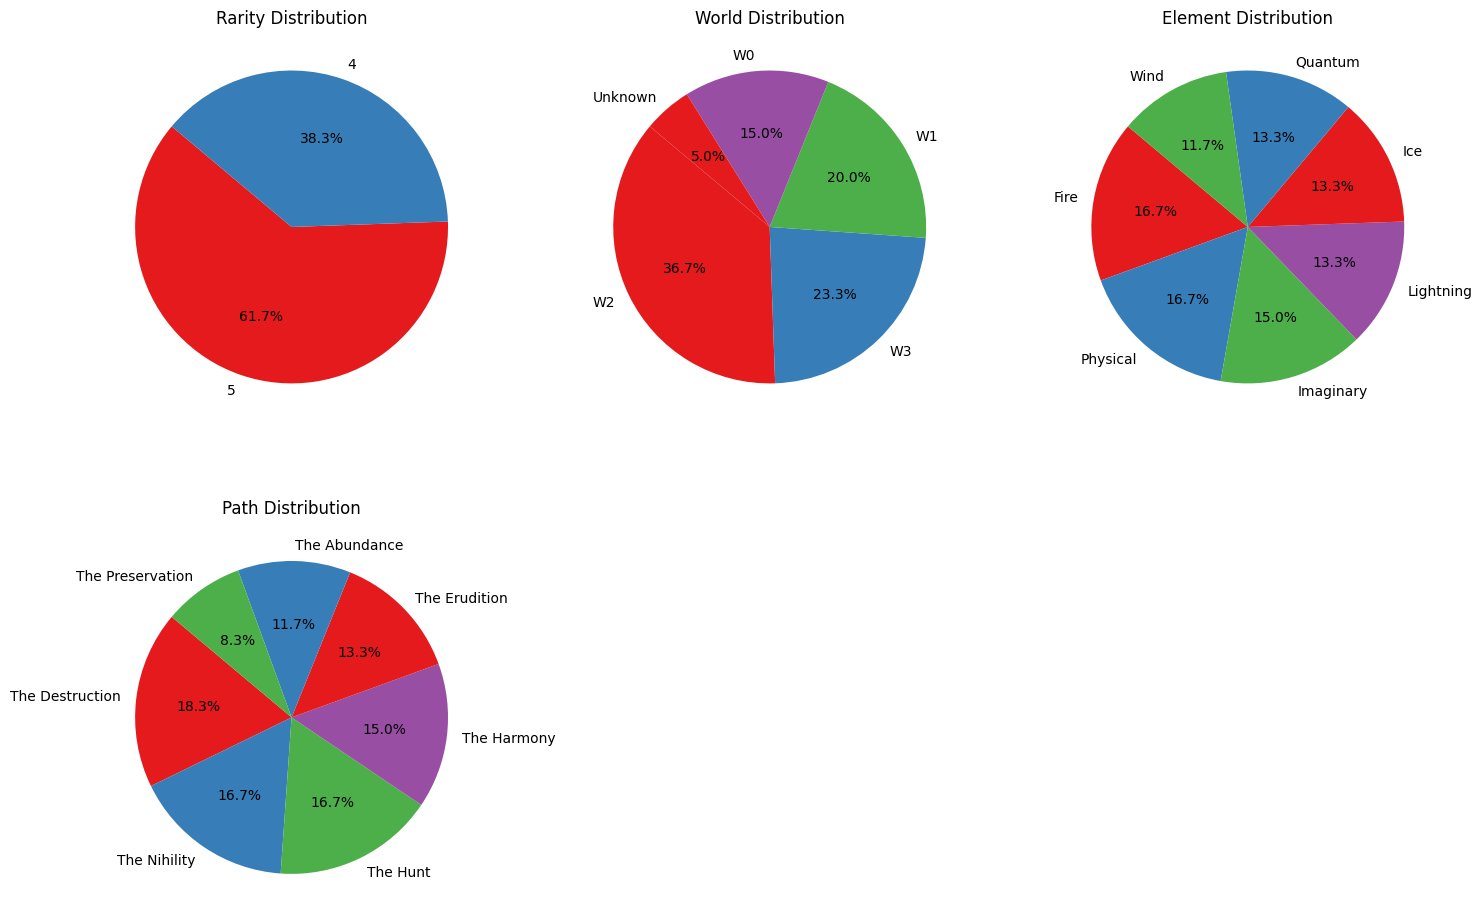

In [6]:
# Define columns to visualize
kolom_1 = ['rarity', 'world', 'element', 'path']

# Set color palette for visualization
color_palette = sns.color_palette("Set1", len(kolom_1))

# Create figure
plt.figure(figsize=(15, 10))

# Loop through each column to generate pie charts
for i, column in enumerate(kolom_1, 1):
    plt.subplot((len(kolom_1) // 3) + 1, 3, i)
    
    # Calculate counts and plot pie chart
    counts = df[column].value_counts()
    plt.pie(counts, labels=counts.index, colors=color_palette, autopct='%1.1f%%', startangle=140)
    
    # Set title
    plt.title(f'{column.capitalize()} Distribution')

# Adjust layout for better spacing
plt.tight_layout()
plt.show()


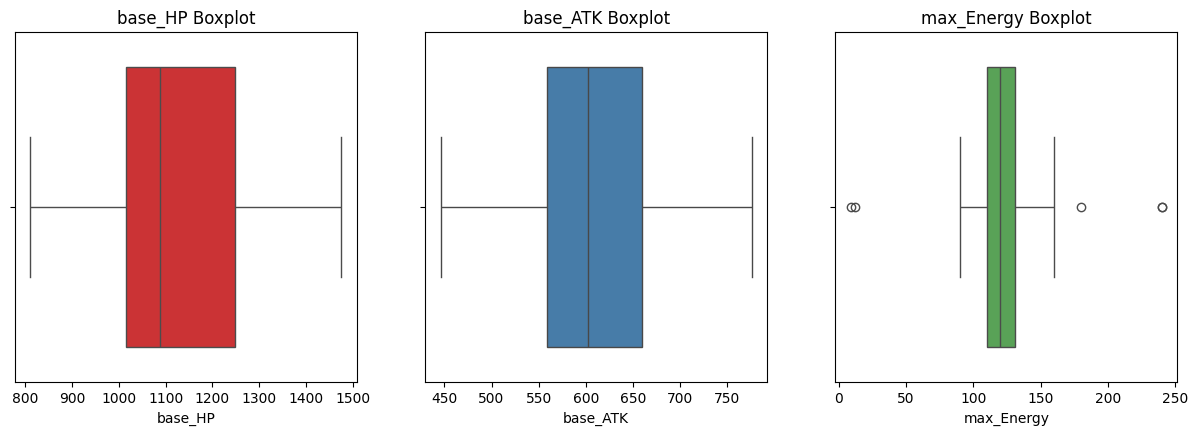

In [7]:
# Sekarang kita coba visualisasi data HP, ATK, dan max_Energy (Menggunakan Box Plot)

kolom_2 = ['base_HP', 'base_ATK', 'max_Energy']

color_palette = sns.color_palette("Set1", len(kolom_2))
plt.figure(figsize = (15, 10))

for i, column in enumerate(kolom_2, 1):
    plt.subplot((len(kolom_2)//3)+1, 3, i)
    sns.boxplot(data=df, x=column, color=color_palette[i - 1])
    plt.xlabel(column)
    plt.title(f'{column} Boxplot')

plt.ion()
plt.show()

<Figure size 2000x1000 with 0 Axes>

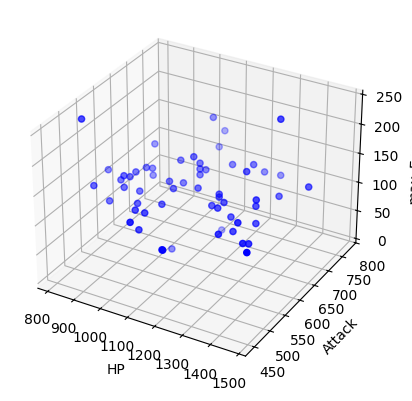

In [8]:

from mpl_toolkits.mplot3d import Axes3D

plt.figure(figsize = (20, 10))
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

x = df['base_HP']
y = df['base_ATK']
z = df['max_Energy']

ax.scatter(x, y, z, c='b', marker='o')
ax.set_xlabel('HP')
ax.set_ylabel('Attack')
ax.set_zlabel('max_Energy')

# plt.ion()
plt.show()


In [9]:
import plotly.graph_objs as go

fig = go.Figure(data=[go.Scatter3d(
    x=df['base_HP'],
    y=df['base_ATK'],
    z=df['max_Energy'],
    mode='markers'
)])

fig.update_layout(
    scene=dict(
        xaxis_title='HP',
        yaxis_title='Attack',
        zaxis_title='max_Energy'
    )
)

fig.show()

In [10]:
df_train = df[kolom_2]
df_train

,base_HP,base_ATK,max_Energy
0,1058,512,120
1,882,547,100
2,1048,757,120
3,1125,621,120
4,1087,679,120
5,1048,640,110
6,1200,600,110
7,1023,512,120
8,953,582,110
9,1242,582,120


In [11]:
# Sekarang kita coba clustering data menggunakan KMeans
# Tapi sebelum itu, kita tentukan nilai K yang paling optimum dengan Elbow Method dan Silhouette Score

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

wcss = []
scores = []
for i in range(2, 10):
    km = KMeans(n_clusters=i, init='k-means++', max_iter=300, n_init=10, random_state=42)
    km.fit(df_train)
    wcss.append(km.inertia_)

    labels = km.labels_
    silhouette_avg = silhouette_score(df_train, labels)
    scores.append(silhouette_avg)
    print('wcss score for n_cluster = ' + str(i) + ' is ' + str(wcss))
    print('silhoutte score for n_clusters = ' + str(i) + ' is ' + str(silhouette_avg))

wcss score for n_cluster = 2 is [882871.0628571428]
silhoutte score for n_clusters = 2 is 0.49312398330814666
wcss score for n_cluster = 3 is [882871.0628571428, 617777.7720685112]
silhoutte score for n_clusters = 3 is 0.40610966013113203
wcss score for n_cluster = 4 is [882871.0628571428, 617777.7720685112, 474614.52759740263]
silhoutte score for n_clusters = 4 is 0.4383568504700967
wcss score for n_cluster = 5 is [882871.0628571428, 617777.7720685112, 474614.52759740263, 353710.8021645021]
silhoutte score for n_clusters = 5 is 0.41324932973743805
wcss score for n_cluster = 6 is [882871.0628571428, 617777.7720685112, 474614.52759740263, 353710.8021645021, 314247.80613275606]
silhoutte score for n_clusters = 6 is 0.40861477168418836
wcss score for n_cluster = 7 is [882871.0628571428, 617777.7720685112, 474614.52759740263, 353710.8021645021, 314247.80613275606, 280963.99155844154]
silhoutte score for n_clusters = 7 is 0.3480678451392202
wcss score for n_cluster = 8 is [882871.0628571428

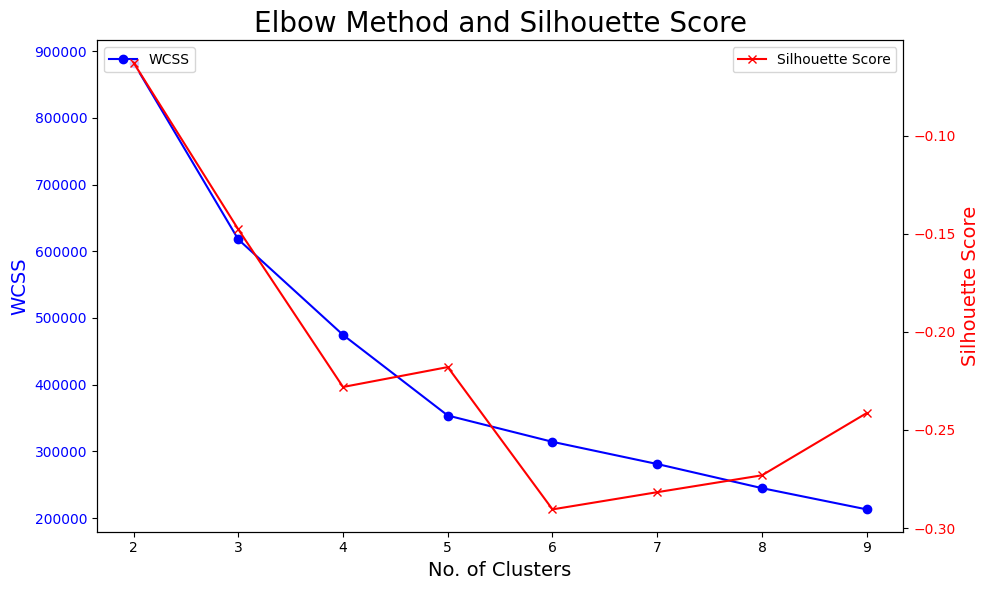

In [20]:
# Import necessary libraries
import matplotlib.pyplot as plt

# Assume 'scores' and 'wcss' are already calculated and available for the range of clusters

# Define the range of clusters
cluster_range = range(2, 10)

# Create a figure and axis
fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot the Elbow Method on the primary y-axis
ax1.plot(cluster_range, wcss, color='b', marker='o', label='WCSS')
ax1.set_xlabel('No. of Clusters', fontsize=14)
ax1.set_ylabel('WCSS', fontsize=14, color='b')
ax1.tick_params(axis='y', labelcolor='b')

# Create a secondary y-axis for the Silhouette Score
ax2 = ax1.twinx()
ax2.plot(cluster_range, scores, color='r', marker='x', label='Silhouette Score')
ax2.set_ylabel('Silhouette Score', fontsize=14, color='r')
ax2.tick_params(axis='y', labelcolor='r')

# Set the title for the plot
plt.title('Elbow Method and Silhouette Score', fontsize=20)

# Display the legend for both metrics
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')

# Show the plot
plt.tight_layout()
plt.show()


# 4,5,6,7,8

In [14]:
# Dari Elbow Method dan Sillhouette Score, kita akan menggunakan K = 3
kmeansmodel = KMeans(n_clusters = 3, init = 'k-means++', max_iter = 300, n_init = 10, random_state = 42)
y_kmeans= kmeansmodel.fit_predict(df_train)

In [22]:
import plotly.graph_objs as go

# Define cluster colors
cluster_colors = ['red', 'blue', 'green']

# Create scatter plots for each cluster
trace1 = go.Scatter3d(
    x=df_train[y_kmeans == 0].iloc[:, 0],
    y=df_train[y_kmeans == 0].iloc[:, 1],
    z=df_train[y_kmeans == 0].iloc[:, 2],
    mode='markers',
    marker=dict(size=8, color=cluster_colors[0], opacity=0.8),
    name='Cluster 1'
)

trace2 = go.Scatter3d(
    x=df_train[y_kmeans == 1].iloc[:, 0],
    y=df_train[y_kmeans == 1].iloc[:, 1],
    z=df_train[y_kmeans == 1].iloc[:, 2],
    mode='markers',
    marker=dict(size=8, color=cluster_colors[1], opacity=0.8),
    name='Cluster 2'
)

trace3 = go.Scatter3d(
    x=df_train[y_kmeans == 2].iloc[:, 0],
    y=df_train[y_kmeans == 2].iloc[:, 1],
    z=df_train[y_kmeans == 2].iloc[:, 2],
    mode='markers',
    marker=dict(size=8, color=cluster_colors[2], opacity=0.8),
    name='Cluster 3'
)

# Create lines between points and centroids for each cluster
lines = []

for cluster_idx, color in enumerate(cluster_colors):
    for i in range(len(df_train[y_kmeans == cluster_idx])):
        lines.append(
            go.Scatter3d(
                x=[df_train.iloc[y_kmeans == cluster_idx, 0].values[i], kmeansmodel.cluster_centers_[cluster_idx, 0]],
                y=[df_train.iloc[y_kmeans == cluster_idx, 1].values[i], kmeansmodel.cluster_centers_[cluster_idx, 1]],
                z=[df_train.iloc[y_kmeans == cluster_idx, 2].values[i], kmeansmodel.cluster_centers_[cluster_idx, 2]],
                mode='lines',
                line=dict(color=color, width=2),
                showlegend=False  # No legend for individual lines
            )
        )

# Scatter plot for centroids
centroids = go.Scatter3d(
    x=kmeansmodel.cluster_centers_[:, 0],
    y=kmeansmodel.cluster_centers_[:, 1],
    z=kmeansmodel.cluster_centers_[:, 2],
    mode='markers',
    marker=dict(size=12, color=cluster_colors, symbol='diamond', opacity=1),
    name='Centroids'
)

# Define layout
layout = go.Layout(
    title='Hasil KMeans Clustering dengan Garis ke Centroid',
    scene=dict(
        xaxis_title='HP',
        yaxis_title='ATK',
        zaxis_title='max_Energy'
    ),
    showlegend=True
)

# Combine traces (clusters, centroids, and lines)
fig = go.Figure(data=[trace1, trace2, trace3, centroids] + lines, layout=layout)

# Show the interactive plot
fig.show()


In [16]:
from sklearn.cluster import AgglomerativeClustering

linkage_col = ['ward', 'complete', 'average', 'single']
scores_all = [[] for _ in range(len(linkage_col))]
for j in range (len(linkage_col)):
    print('Linkage: ', linkage_col[j])
    scores = []
    for i in range(2, 10):
        AC = AgglomerativeClustering(n_clusters=i, linkage = linkage_col[j]) # Menggunakan Ward Method
        AC.fit(df_train)

        labels = AC.labels_
        silhouette_avg = silhouette_score(df_train, labels)
        scores.append(silhouette_avg)
        print('silhoutte score for n_clusters = ' + str(i) + ' is ' + str(silhouette_avg))
    print("\n##########################\n")
    scores_all[j] = scores

Linkage:  ward
silhoutte score for n_clusters = 2 is 0.48327759516530894
silhoutte score for n_clusters = 3 is 0.40324599483673995
silhoutte score for n_clusters = 4 is 0.4406103186583741
silhoutte score for n_clusters = 5 is 0.40751690869524815
silhoutte score for n_clusters = 6 is 0.39848379233813985
silhoutte score for n_clusters = 7 is 0.3900688986668791
silhoutte score for n_clusters = 8 is 0.4059871986830424
silhoutte score for n_clusters = 9 is 0.3520664911369965

##########################

Linkage:  complete
silhoutte score for n_clusters = 2 is 0.48327759516530894
silhoutte score for n_clusters = 3 is 0.3218922060809652
silhoutte score for n_clusters = 4 is 0.315795731997996
silhoutte score for n_clusters = 5 is 0.2576713125119366
silhoutte score for n_clusters = 6 is 0.29329516320114885
silhoutte score for n_clusters = 7 is 0.2858609922821805
silhoutte score for n_clusters = 8 is 0.29518586679584885
silhoutte score for n_clusters = 9 is 0.28355234326531487

#################

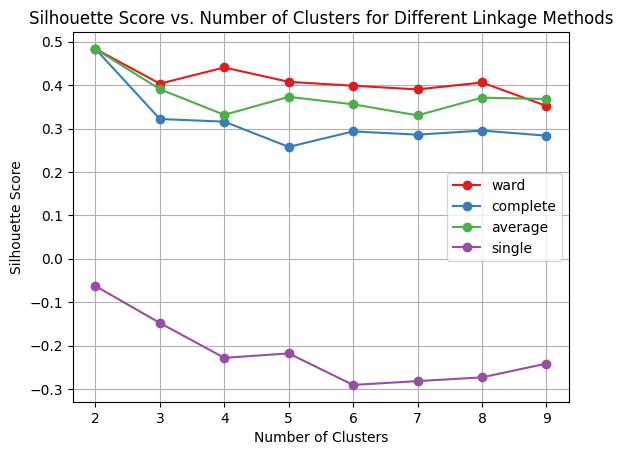

In [17]:
colors = sns.color_palette("Set1", len(linkage_col))

for j in range(len(linkage_col)):
    plt.plot(range(2, 10), scores_all[j], marker='o', color=colors[j], label=linkage_col[j])

plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score vs. Number of Clusters for Different Linkage Methods')
plt.legend()
plt.grid(True)
plt.show()

In [23]:
import plotly.graph_objs as go
import numpy as np

# Perform Agglomerative Clustering
banyak_cluster = 3
AC = AgglomerativeClustering(n_clusters=banyak_cluster, linkage='average')
labels = AC.fit_predict(df_train)

# Combine labels with the training data
df_train_with_labels = np.column_stack((df_train, labels))

# Calculate centroids for each cluster
centroids = []
for cluster_label in range(banyak_cluster):
    cluster_data = df_train_with_labels[df_train_with_labels[:, -1] == cluster_label]
    cluster_centroid = np.mean(cluster_data[:, :-1], axis=0)
    centroids.append(cluster_centroid)
centroids = np.array(centroids)

# Define cluster colors
colors = ['red', 'blue', 'green']

# Create traces for each cluster and lines connecting points to centroids
traces = []
lines = []

for cluster_label in range(banyak_cluster):
    cluster_data = df_train_with_labels[df_train_with_labels[:, -1] == cluster_label]
    
    # Scatter plot for each cluster
    trace = go.Scatter3d(
        x=cluster_data[:, 0],
        y=cluster_data[:, 1],
        z=cluster_data[:, 2],
        mode='markers',
        marker=dict(size=8, color=colors[cluster_label], opacity=0.8),
        name=f'Cluster {cluster_label + 1}'
    )
    traces.append(trace)
    
    # Create lines connecting each point to its centroid
    for i in range(len(cluster_data)):
        lines.append(
            go.Scatter3d(
                x=[cluster_data[i, 0], centroids[cluster_label, 0]],
                y=[cluster_data[i, 1], centroids[cluster_label, 1]],
                z=[cluster_data[i, 2], centroids[cluster_label, 2]],
                mode='lines',
                line=dict(color=colors[cluster_label], width=2),
                showlegend=False  # Don't show legend for lines
            )
        )

# Scatter plot for centroids
centroid_trace = go.Scatter3d(
    x=centroids[:, 0],
    y=centroids[:, 1],
    z=centroids[:, 2],
    mode='markers',
    marker=dict(size=12, color=colors, symbol='diamond', opacity=1),
    name='Centroids'
)

# Add centroid trace and lines to the figure
traces.append(centroid_trace)
traces.extend(lines)

# Create the layout for the plot
layout = go.Layout(
    title='Hasil Agglomerative Clustering 3D dengan Garis ke Centroid',
    scene=dict(
        xaxis_title='HP',
        yaxis_title='ATK',
        zaxis_title='max_Energy'
    ),
    showlegend=True
)

# Generate the figure
fig = go.Figure(data=traces, layout=layout)
fig.show()


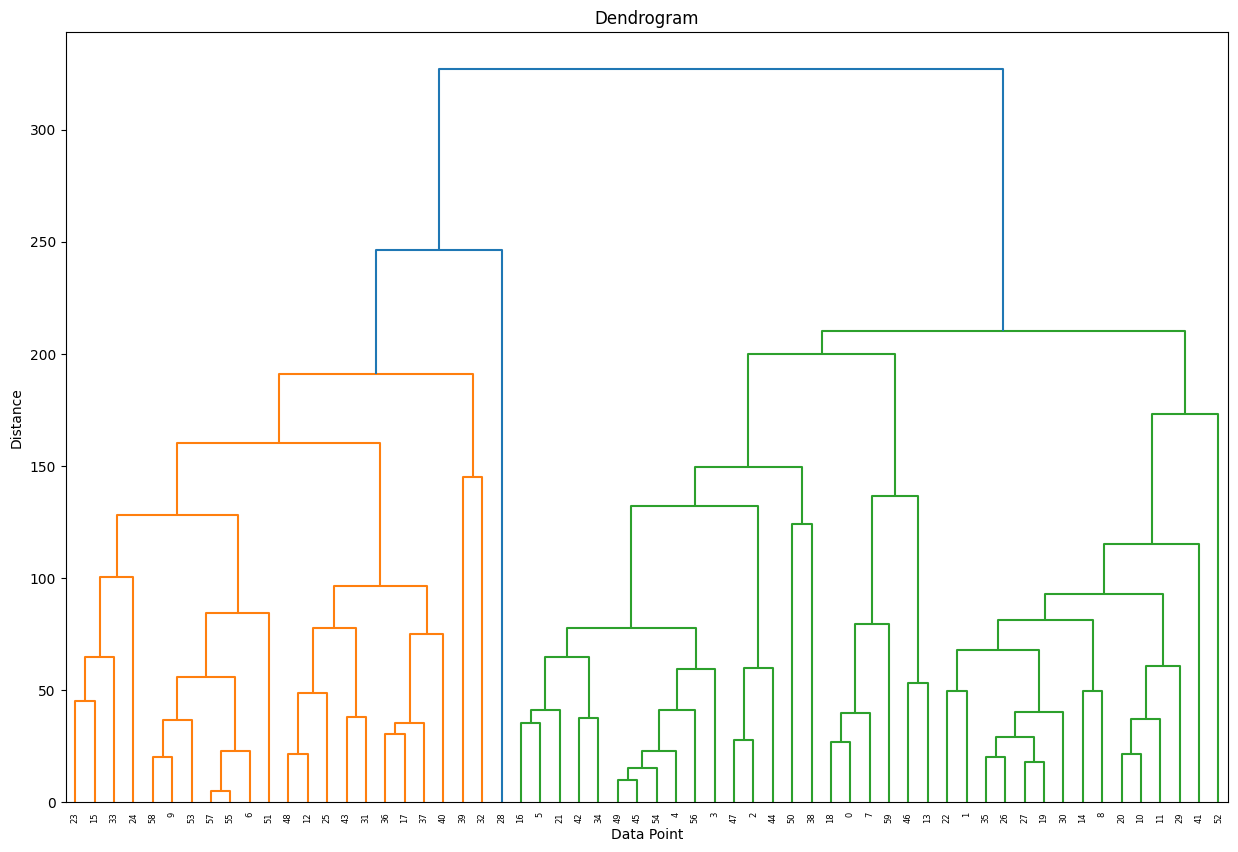

In [19]:
import scipy.cluster.hierarchy as sch

linked = sch.linkage(df_train, 'average')


plt.figure(figsize=(15, 10))
dendrogram = sch.dendrogram(linked, orientation='top',distance_sort='descending', show_leaf_counts=True)
plt.title('Dendrogram')
plt.xlabel('Data Point')
plt.ylabel('Distance')
plt.axhline(y=1500, color='black', linestyle='--') # at this point, will divide the data into 3 clusters
plt.show()